In this script, I replicated Figure 15 from Clément Soriot's work to characterize Clusters 8 to 15, all of which feature a 100% sea ice concentration.

The analysis relies on the following description:
"Clusters 8 to 11 represent increasing sea ice thickness, with strongly increasing TB at 1.4 GHz, whereas the other frequencies are not changing much. [...] From Cluster 12 to 15, scattering at 18 and 36 GHz increases. In winter, these Clusters are mainly located north of Greenland (Fig. 8): they are likely due to depth hoar over multi-year ice and their extent increases from October to May, and then decreases until disappearing in summer."

A RMSE reduction was used. Finally, the code includes the exact cluster definitions used by Clément Soriot, which I obtained at a later stage.

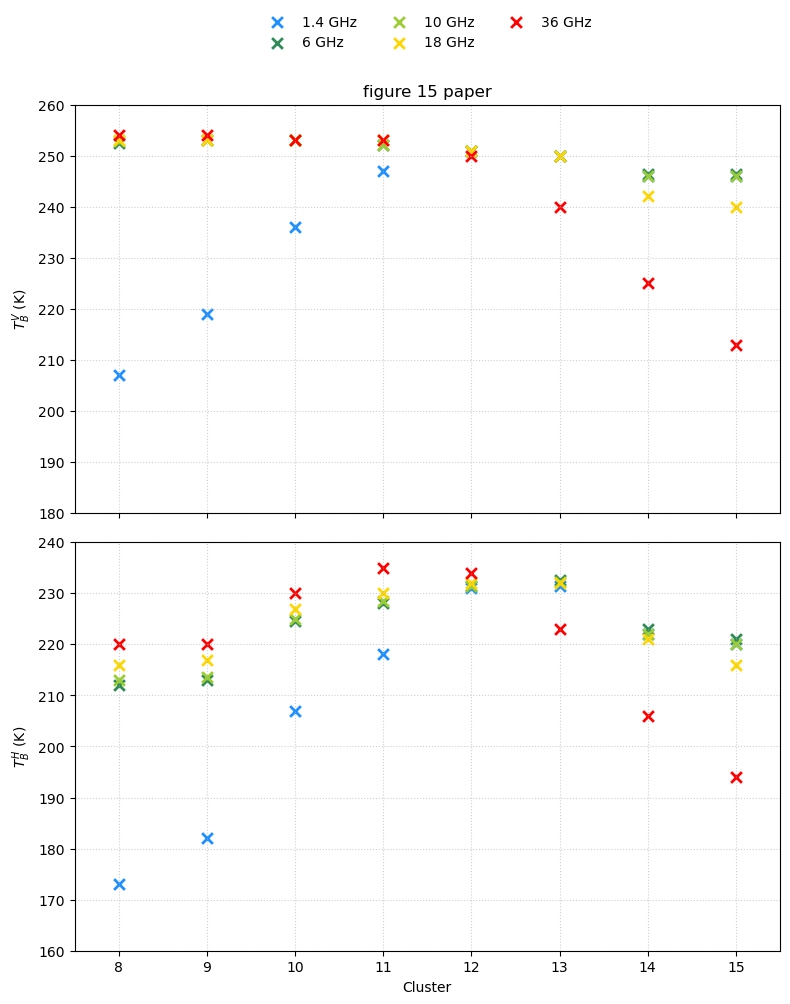

In [1]:
#date read on paper, fig 15
import matplotlib.pyplot as plt
import numpy as np

# Clusters 8 à 15
clusters = np.arange(8, 16)

# Données SMRT extraites (Croix uniquement)
# Format : [Cluster 8, 9, 10, 11, 12, 13, 14, 15]
data_smrt = {
    '1.4':  {'V': [207, 219, 236, 247, 251, 250, 246, 246],       'H': [173, 182, 207, 218, 231, 231.5, 222, 220]},
    '6.9':  {'V': [252.5, 253, 253, 252, 251, 250, 246.5, 246.5], 'H': [212, 213, 224.5, 228, 231.5, 232.5, 223, 221]},
    '10.6': {'V': [252.8, 253, 253, 252, 251, 250, 246, 246],     'H': [213, 213.5, 225, 228.5, 231.5, 232.2, 222, 220]},
    '18.7': {'V': [253, 253, 253, 253, 251, 250, 242, 240],       'H': [216, 217, 227, 230, 232, 232, 221, 216]},
    '36.5': {'V': [254, 254, 253, 253, 250, 240, 225, 213],       'H': [220, 220, 230, 235, 234, 223, 206, 194]}
}

colors = {'1.4': '#1E90FF', '6.9': '#2E8B57', '10.6': '#9ACD32', '18.7': '#FFD700', '36.5': '#FF0000'}
labels = {'1.4': '1.4 GHz', '6.9': '6 GHz', '10.6': '10 GHz', '18.7': '18 GHz', '36.5': '36 GHz'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

for freq in ['1.4', '6.9', '10.6', '18.7', '36.5']:
    ax1.scatter(clusters, data_smrt[freq]['V'], marker='x', s=60, color=colors[freq], label=labels[freq], linewidths=2)
    ax2.scatter(clusters, data_smrt[freq]['H'], marker='x', s=60, color=colors[freq], linewidths=2)

# Mise en forme
ax1.set_ylabel('$T_B^V$ (K)')
ax1.set_ylim(180, 260)
ax1.set_title('figure 15 paper')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=3, frameon=False)

ax2.set_ylabel('$T_B^H$ (K)')
ax2.set_xlabel('Cluster')
ax2.set_ylim(160, 240)
ax2.set_xticks(clusters)

for ax in [ax1, ax2]:
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlim(7.5, 15.5)

plt.tight_layout()
plt.show()

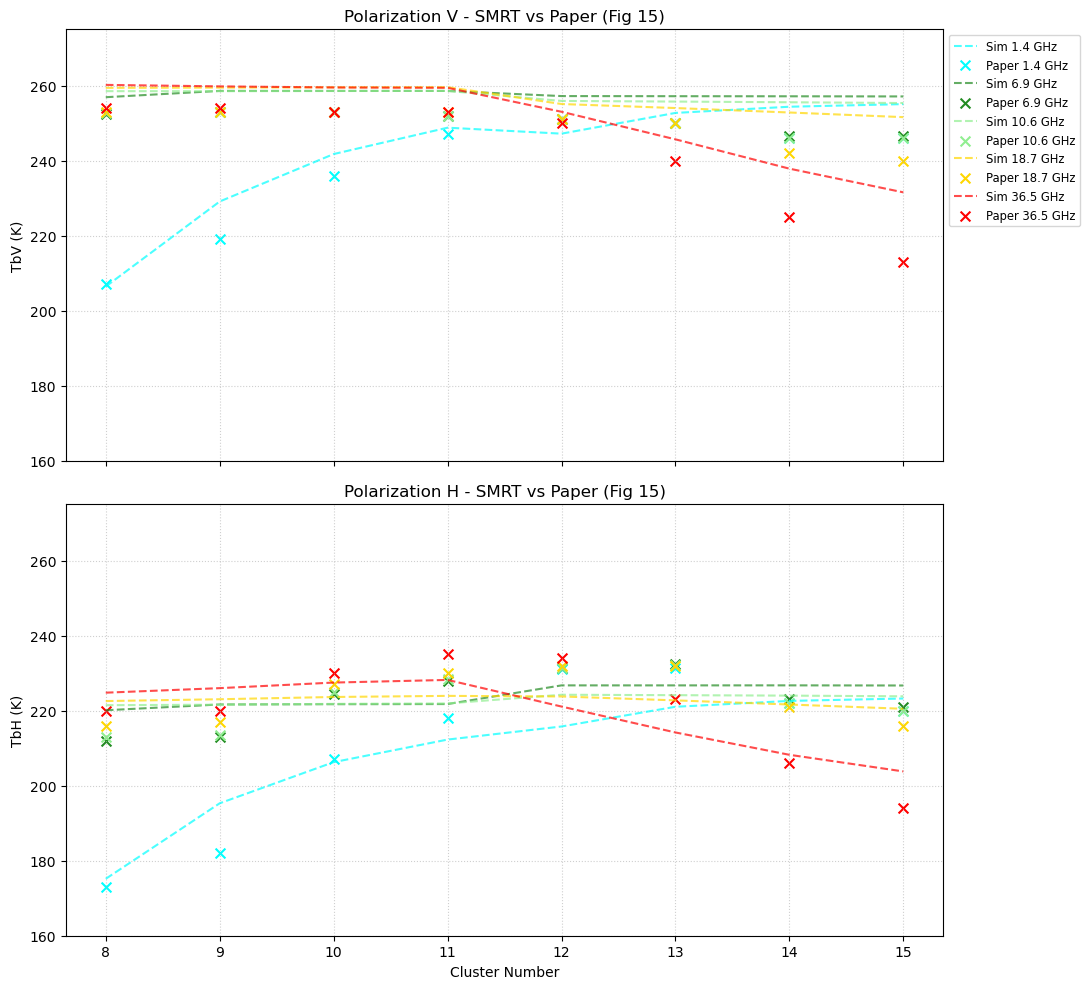


ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS
           1.4V_Err 1.4H_Err 6.9V_Err 6.9H_Err 10.6V_Err 10.6H_Err 18.7V_Err 18.7H_Err 36.5V_Err 36.5H_Err   RMSE_V   RMSE_H RMSE_Total
Cluster                                                                                                                                
Cluster 08   -0.6 K   +2.2 K   +4.4 K   +8.1 K    +5.7 K    +8.5 K    +6.4 K    +6.6 K    +6.2 K    +4.8 K   5.13 K   6.46 K     5.84 K
Cluster 09  +10.1 K  +13.3 K   +5.6 K   +8.7 K    +5.5 K    +8.1 K    +6.5 K    +6.1 K    +5.8 K    +6.0 K   6.91 K   8.84 K     7.93 K
Cluster 10   +5.7 K   -0.7 K   +5.6 K   -2.8 K    +5.6 K    -3.2 K    +6.5 K    -3.3 K    +6.5 K    -2.5 K   6.00 K   2.67 K     4.64 K
Cluster 11   +1.8 K   -5.7 K   +6.6 K   -6.2 K    +6.6 K    -6.6 K    +6.6 K    -6.0 K    +6.4 K    -6.8 K   5.90 K   6.28 K     6.09 K
Cluster 12   -3.8 K  -15.2 K   +6.2 K   -4.7 K    +4.9 K    -7.2 K    +4.1 K    -8.2 K    +3.0 K   -12.9 K   4.54 K  10.39 K     8.02

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

# Definition of interfaces according to the paper methodology
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")

# --- Permanent Substrate (Ocean) ---
ocean = make_water_body(temperature=272, salinity=30 * PSU)

# List to store results for each cluster
all_results = []

# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================

# Cluster 8
snow_8 = make_snowpack(  
    thickness=[0.02],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[265],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_8 = make_ice_column(ice_type="firstyear", thickness=[0.1], density=[917],
                        temperature=[265], salinity=[10*PSU], brine_volume_fraction=0.11,
                        microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                        stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_8 + ice_8 + ocean))

# Cluster 9
snow_9 = make_snowpack(  
    thickness=[0.10],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[265],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_9 = make_ice_column(ice_type="firstyear", thickness=[0.20], density=[917],
                        temperature=[265], salinity=[10*PSU], brine_volume_fraction=0.11,
                        microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                        stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_9 + ice_9 + ocean))

# Cluster 10
snow_10 = make_snowpack(  
    thickness=[0.20],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[265],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_10 = make_ice_column(ice_type="firstyear", thickness=[0.30], density=[917],
                         temperature=[265], salinity=[10*PSU], brine_volume_fraction=0.11,
                         microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                         stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_10 + ice_10 + ocean))

# Cluster 11
snow_11 = make_snowpack(  
    thickness=[0.25],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[265],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_11 = make_ice_column(ice_type="firstyear", thickness=[0.40], density=[917],
                         temperature=[265], salinity=[10*PSU], brine_volume_fraction=0.11,
                         microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                         stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_11 + ice_11 + ocean))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

# Cluster 12
total_depth_12 = 0.01
ws_12 = make_snowpack(thickness=[0.6*total_depth_12], density=[350], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_12 = make_snowpack(thickness=[0.4*total_depth_12], density=[200], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_12 = make_ice_column(ice_type="multiyear", thickness=[1.0], density=[850], temperature=[265], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_12 + dh_12 + ice_my_12 + ocean))

# Cluster 13
total_depth_13 = 0.10
ws_13 = make_snowpack(thickness=[0.6*total_depth_13], density=[350], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_13 = make_snowpack(thickness=[0.4*total_depth_13], density=[200], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_13 = make_ice_column(ice_type="multiyear", thickness=[1.5], density=[850], temperature=[265], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_13 + dh_13 + ice_my_13 + ocean))

# Cluster 14
total_depth_14 = 0.20
ws_14 = make_snowpack(thickness=[0.6*total_depth_14], density=[350], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_14 = make_snowpack(thickness=[0.4*total_depth_14], density=[200], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_14 = make_ice_column(ice_type="multiyear", thickness=[1.8], density=[850], temperature=[265], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_14 + dh_14 + ice_my_14 + ocean))

# Cluster 15
total_depth_15 = 0.30
ws_15 = make_snowpack(thickness=[0.6*total_depth_15], density=[350], temperature=[265],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_15 = make_snowpack(thickness=[0.4*total_depth_15], density=[200], temperature=[260],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_15 = make_ice_column(ice_type="multiyear", thickness=[2.0], density=[850], temperature=[265], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_15 + dh_15 + ice_my_15 + ocean))


# =================================================================
# Data from the paper (Figure 15)
# =================================================================
data_paper_v = {
    '1.4':  [207.0, 219.0, 236.0, 247.0, 251.0, 250.0, 246.0, 246.0],
    '6.9':  [252.5, 253.0, 253.0, 252.0, 251.0, 250.0, 246.5, 246.5],
    '10.6': [252.8, 253.0, 253.0, 252.0, 251.0, 250.0, 246.0, 246.0],
    '18.7': [253.0, 253.0, 253.0, 253.0, 251.0, 250.0, 242.0, 240.0],
    '36.5': [254.0, 254.0, 253.0, 253.0, 250.0, 240.0, 225.0, 213.0]
}

data_paper_h = {
    '1.4':  [173.0, 182.0, 207.0, 218.0, 231.0, 231.5, 222.0, 220.0],
    '6.9':  [212.0, 213.0, 224.5, 228.0, 231.5, 232.5, 223.0, 221.0],
    '10.6': [213.0, 213.5, 225.0, 228.5, 231.5, 232.2, 222.0, 220.0],
    '18.7': [216.0, 217.0, 227.0, 230.0, 232.0, 232.0, 221.0, 216.0],
    '36.5': [220.0, 220.0, 230.0, 235.0, 234.0, 223.0, 206.0, 194.0]
}

# =================================================================
# PLOTTING RESULTS (V and H Polarizations)
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
colors = ['cyan', 'forestgreen', 'lightgreen', 'gold', 'red']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}

fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

for p_idx, pol in enumerate(pols):
    ax = axes[p_idx]
    paper_dict = data_papers[pol]
    
    for i, f in enumerate(freqs):
        tb_list = []
        for res in all_results:
            val = res.data.sel(polarization=pol).sel(frequency=f, method='nearest')
            tb_list.append(val.item())
        
        # Plot Simulation
        ax.plot(clusters, tb_list, '--', color=colors[i], alpha=0.7, label=f'Sim {freq_keys[i]} GHz')
        
        # Plot Paper Data
        ax.scatter(clusters, paper_dict[freq_keys[i]], marker='x', s=50, 
                   color=colors[i], linewidths=1.5, label=f'Paper {freq_keys[i]} GHz')

    ax.set_ylabel(f'Tb{pol} (K)')
    ax.set_title(f'Polarization {pol} - SMRT vs Paper (Fig 15)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(160, 275)
    if p_idx == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

plt.xlabel('Cluster Number')
plt.tight_layout()
plt.show()

# =================================================================
# ERROR CALCULATION & TABLE GENERATION
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}

rows_list = []

for idx, cluster_id in enumerate(clusters):
    res = all_results[idx]
    row_data = {'Cluster': f"Cluster {cluster_id:02d}"}
    
    all_squared_errors = []
    v_squared_errors = []
    h_squared_errors = []
    
    for f_idx, f in enumerate(freqs):
        f_key = freq_keys[f_idx]
        for pol in pols:
            # Retrieve SMRT simulation value
            tb_sim = res.data.sel(polarization=pol).sel(frequency=f, method='nearest').item()
            # Retrieve paper target value (aligning indices from 0 to 7)
            tb_paper = data_papers[pol][f_key][idx]
            
            # Calculate individual error (Difference in Kelvin)
            error = tb_sim - tb_paper
            row_data[f"{f_key}{pol}_Err"] = f"{error:+.1f} K"
            
            # Store values for aggregate RMSE calculations
            sq_err = error ** 2
            all_squared_errors.append(sq_err)
            if pol == 'V':
                v_squared_errors.append(sq_err)
            else:
                h_squared_errors.append(sq_err)
                
    # Calculate RMSE metrics
    row_data['RMSE_V'] = f"{np.sqrt(np.mean(v_squared_errors)):.2f} K"
    row_data['RMSE_H'] = f"{np.sqrt(np.mean(h_squared_errors)):.2f} K"
    row_data['RMSE_Total'] = f"{np.sqrt(np.mean(all_squared_errors)):.2f} K"
    
    rows_list.append(row_data)

# Create and display the results table using Pandas
df_errors = pd.DataFrame(rows_list).set_index('Cluster')

print("\n" + "="*80)
print("ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS")
print("="*80)
# Force display of all columns in the console output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_errors)
print("="*80 + "\n")

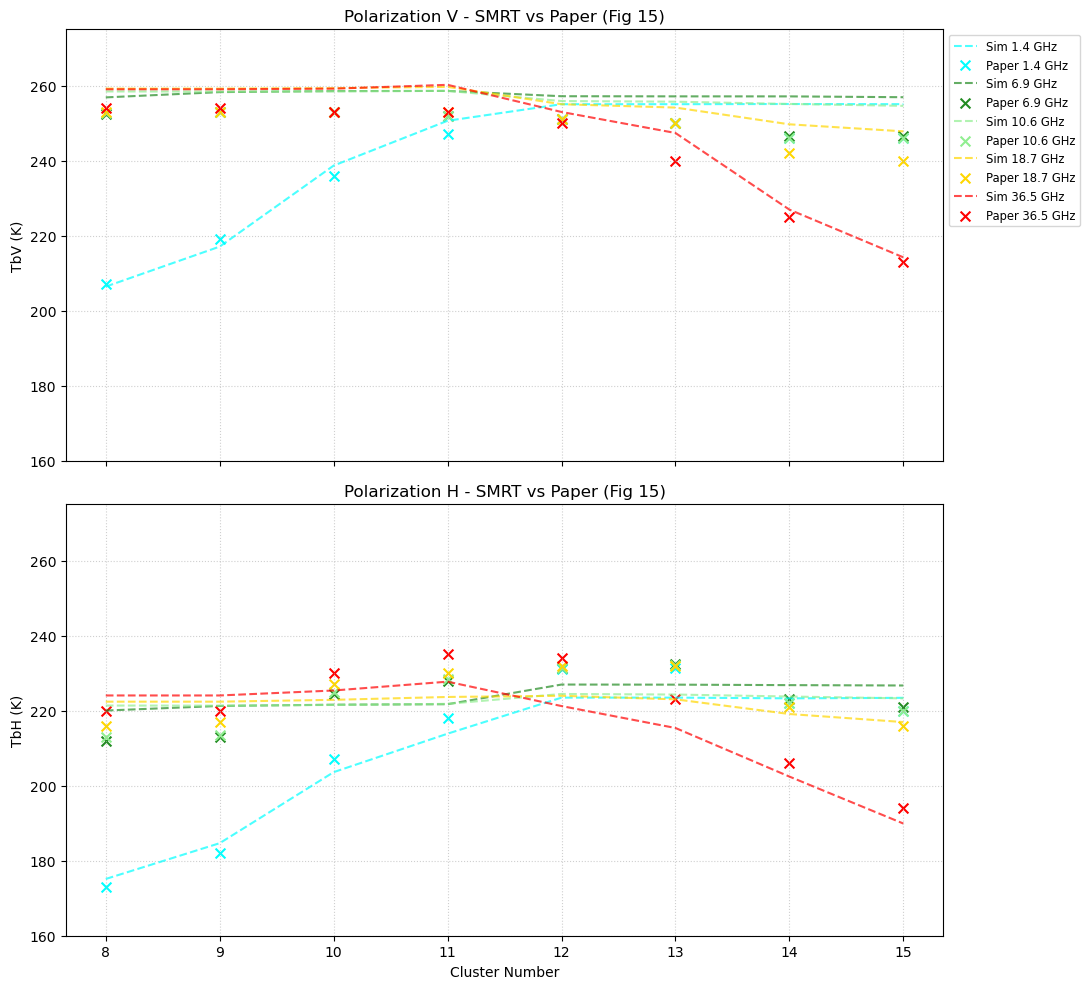


ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS
           1.4V_Err 1.4H_Err 6.9V_Err 6.9H_Err 10.6V_Err 10.6H_Err 18.7V_Err 18.7H_Err 36.5V_Err 36.5H_Err  RMSE_V  RMSE_H RMSE_Total
Cluster                                                                                                                              
Cluster 08   -0.6 K   +2.1 K   +4.4 K   +8.0 K    +5.6 K    +8.4 K    +6.2 K    +6.4 K    +5.0 K    +4.1 K  4.79 K  6.28 K     5.58 K
Cluster 09   -1.9 K   +2.7 K   +5.3 K   +8.3 K    +5.4 K    +7.9 K    +6.2 K    +5.4 K    +5.0 K    +4.1 K  4.98 K  6.05 K     5.54 K
Cluster 10   +2.7 K   -3.4 K   +5.5 K   -2.9 K    +5.5 K    -3.5 K    +6.3 K    -4.1 K    +6.2 K    -4.6 K  5.40 K  3.74 K     4.64 K
Cluster 11   +3.6 K   -4.1 K   +6.6 K   -6.3 K    +6.6 K    -6.7 K    +6.7 K    -6.3 K    +7.2 K    -7.3 K  6.26 K  6.22 K     6.24 K
Cluster 12   +4.0 K   -7.5 K   +6.2 K   -4.5 K    +4.9 K    -7.0 K    +4.0 K    -8.0 K    +3.0 K   -12.8 K  4.54 K  8.41 K     6.76 K
Cluster 13 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

# Definition of interfaces according to the paper methodology
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")

# --- Permanent Substrate (Ocean) ---
ocean = make_water_body(temperature=272, salinity=30 * PSU)

# List to store results for each cluster
all_results = []

# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================

# Cluster 8
snow_8 = make_snowpack(  
    thickness=[0.06],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[230.0],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_8 = make_ice_column(ice_type="firstyear", thickness=[0.10], density=[917],
                        temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11,
                        microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                        stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_8 + ice_8 + ocean))

# Cluster 9
snow_9 = make_snowpack(  
    thickness=[0.06],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[230.0],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_9 = make_ice_column(ice_type="firstyear", thickness=[0.14], density=[917],
                        temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11,
                        microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                        stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_9 + ice_9 + ocean))

# Cluster 10
snow_10 = make_snowpack(  
    thickness=[0.11],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[257.0],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_10 = make_ice_column(ice_type="firstyear", thickness=[0.27], density=[917],
                         temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11,
                         microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                         stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_10 + ice_10 + ocean))

# Cluster 11
snow_11 = make_snowpack(  
    thickness=[0.16],  
    microstructure_model="sticky_hard_spheres",  
    density=[350],  
    temperature=[270.0],  
    radius=[0.16e-3], 
    stickiness=[0.18],  
)  

ice_11 = make_ice_column(ice_type="firstyear", thickness=[0.44], density=[917],
                         temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11,
                         microstructure_model="sticky_hard_spheres", radius=[0.1e-3], 
                         stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_11 + ice_11 + ocean))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

# Cluster 12
total_depth_12 = 0.01
ws_12 = make_snowpack(thickness=[0.6*total_depth_12], density=[350], temperature=[230.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_12 = make_snowpack(thickness=[0.4*total_depth_12], density=[200], temperature=[255.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_12 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_12 + dh_12 + ice_my_12 + ocean))

# Cluster 13
total_depth_13 = 0.07
ws_13 = make_snowpack(thickness=[0.6*total_depth_13], density=[350], temperature=[230.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_13 = make_snowpack(thickness=[0.4*total_depth_13], density=[200], temperature=[255.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_13 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_13 + dh_13 + ice_my_13 + ocean))

# Cluster 14
total_depth_14 = 0.51
ws_14 = make_snowpack(thickness=[0.6*total_depth_14], density=[350], temperature=[269.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_14 = make_snowpack(thickness=[0.4*total_depth_14], density=[200], temperature=[266.1],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_14 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_14 + dh_14 + ice_my_14 + ocean))

# Cluster 15
total_depth_15 = 0.51
ws_15 = make_snowpack(thickness=[0.6*total_depth_15], density=[350], temperature=[240.0],
                      microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_15 = make_snowpack(thickness=[0.4*total_depth_15], density=[200], temperature=[257.9],
                      microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)

ice_my_15 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU],
                            microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2],  
                            brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_15 + dh_15 + ice_my_15 + ocean))


# =================================================================
# Data from the paper (Figure 15)
# =================================================================
data_paper_v = {
    '1.4':  [207.0, 219.0, 236.0, 247.0, 251.0, 250.0, 246.0, 246.0],
    '6.9':  [252.5, 253.0, 253.0, 252.0, 251.0, 250.0, 246.5, 246.5],
    '10.6': [252.8, 253.0, 253.0, 252.0, 251.0, 250.0, 246.0, 246.0],
    '18.7': [253.0, 253.0, 253.0, 253.0, 251.0, 250.0, 242.0, 240.0],
    '36.5': [254.0, 254.0, 253.0, 253.0, 250.0, 240.0, 225.0, 213.0]
}

data_paper_h = {
    '1.4':  [173.0, 182.0, 207.0, 218.0, 231.0, 231.5, 222.0, 220.0],
    '6.9':  [212.0, 213.0, 224.5, 228.0, 231.5, 232.5, 223.0, 221.0],
    '10.6': [213.0, 213.5, 225.0, 228.5, 231.5, 232.2, 222.0, 220.0],
    '18.7': [216.0, 217.0, 227.0, 230.0, 232.0, 232.0, 221.0, 216.0],
    '36.5': [220.0, 220.0, 230.0, 235.0, 234.0, 223.0, 206.0, 194.0]
}


# =================================================================
# PLOTTING RESULTS (V and H Polarizations)
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
colors = ['cyan', 'forestgreen', 'lightgreen', 'gold', 'red']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}


fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)


for p_idx, pol in enumerate(pols):
    ax = axes[p_idx]
    paper_dict = data_papers[pol]
    
    for i, f in enumerate(freqs):
        tb_list = []
        for res in all_results:
            val = res.data.sel(polarization=pol).sel(frequency=f, method='nearest')
            tb_list.append(val.item())
        
        # Plot Simulation
        ax.plot(clusters, tb_list, '--', color=colors[i], alpha=0.7, label=f'Sim {freq_keys[i]} GHz')
        
        # Plot Paper Data
        ax.scatter(clusters, paper_dict[freq_keys[i]], marker='x', s=50, 
                   color=colors[i], linewidths=1.5, label=f'Paper {freq_keys[i]} GHz')

    ax.set_ylabel(f'Tb{pol} (K)')
    ax.set_title(f'Polarization {pol} - SMRT vs Paper (Fig 15)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(160, 275)
    if p_idx == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

plt.xlabel('Cluster Number')
plt.tight_layout()
plt.show()


# =================================================================
# ERROR CALCULATION & TABLE GENERATION
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}

rows_list = []


for idx, cluster_id in enumerate(clusters):
    res = all_results[idx]
    row_data = {'Cluster': f"Cluster {cluster_id:02d}"}
    
    all_squared_errors = []
    v_squared_errors = []
    h_squared_errors = []
    
    for f_idx, f in enumerate(freqs):
        f_key = freq_keys[f_idx]
        for pol in pols:
            # Retrieve SMRT simulation value
            tb_sim = res.data.sel(polarization=pol).sel(frequency=f, method='nearest').item()
            # Retrieve paper target value (aligning indices from 0 to 7)
            tb_paper = data_papers[pol][f_key][idx]
            
            # Calculate individual error (Difference in Kelvin)
            error = tb_sim - tb_paper
            row_data[f"{f_key}{pol}_Err"] = f"{error:+.1f} K"
            
            # Store values for aggregate RMSE calculations
            sq_err = error ** 2
            all_squared_errors.append(sq_err)
            if pol == 'V':
                v_squared_errors.append(sq_err)
            else:
                h_squared_errors.append(sq_err)
                
    # Calculate RMSE metrics
    row_data['RMSE_V'] = f"{np.sqrt(np.mean(v_squared_errors)):.2f} K"
    row_data['RMSE_H'] = f"{np.sqrt(np.mean(h_squared_errors)):.2f} K"
    row_data['RMSE_Total'] = f"{np.sqrt(np.mean(all_squared_errors)):.2f} K"
    
    rows_list.append(row_data)


# Create and display the results table using Pandas
df_errors = pd.DataFrame(rows_list).set_index('Cluster')


print("\n" + "="*80)
print("ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS")
print("="*80)
# Force display of all columns in the console output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_errors)
print("="*80 + "\n")

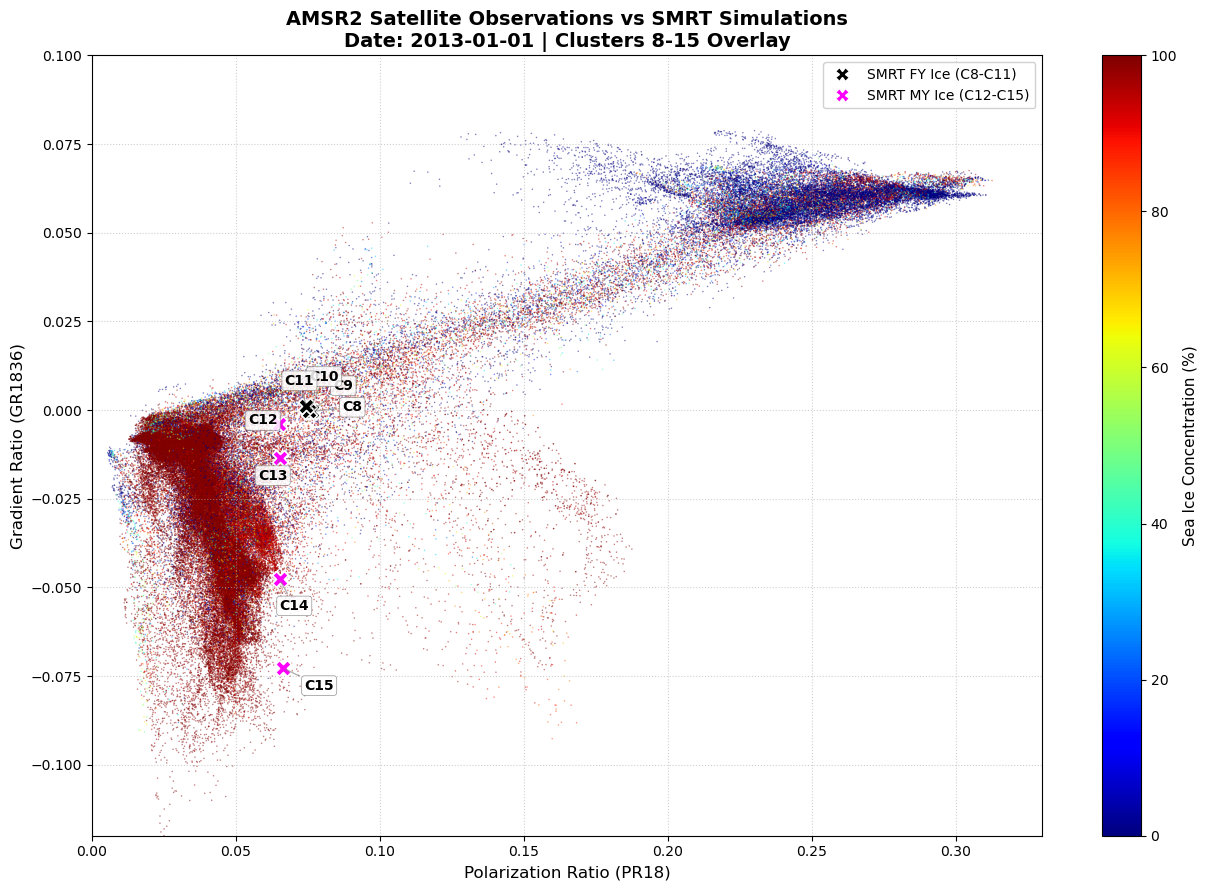

In [13]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# --- CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice) ---
# Cluster 8
snow_8 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_8 = make_ice_column(ice_type="firstyear", thickness=[0.10], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_8 + ice_8 + ocean))

# Cluster 9
snow_9 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_9 = make_ice_column(ice_type="firstyear", thickness=[0.14], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_9 + ice_9 + ocean))

# Cluster 10
snow_10 = make_snowpack(thickness=[0.11], microstructure_model="sticky_hard_spheres", density=[350], temperature=[257.0], radius=[0.16e-3], stickiness=[0.18])
ice_10 = make_ice_column(ice_type="firstyear", thickness=[0.27], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_10 + ice_10 + ocean))

# Cluster 11
snow_11 = make_snowpack(thickness=[0.16], microstructure_model="sticky_hard_spheres", density=[350], temperature=[270.0], radius=[0.16e-3], stickiness=[0.18])
ice_11 = make_ice_column(ice_type="firstyear", thickness=[0.44], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_11 + ice_11 + ocean))

# --- CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow) ---
# Cluster 12
total_depth_12 = 0.01
ws_12 = make_snowpack(thickness=[0.6*total_depth_12], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_12 = make_snowpack(thickness=[0.4*total_depth_12], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_12 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_12 + dh_12 + ice_my_12 + ocean))

# Cluster 13
total_depth_13 = 0.07
ws_13 = make_snowpack(thickness=[0.6*total_depth_13], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_13 = make_snowpack(thickness=[0.4*total_depth_13], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_13 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_13 + dh_13 + ice_my_13 + ocean))

# Cluster 14
total_depth_14 = 0.51
ws_14 = make_snowpack(thickness=[0.6*total_depth_14], density=[350], temperature=[269.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_14 = make_snowpack(thickness=[0.4*total_depth_14], density=[200], temperature=[266.1], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_14 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_14 + dh_14 + ice_my_14 + ocean))

# Cluster 15
total_depth_15 = 0.51
ws_15 = make_snowpack(thickness=[0.6*total_depth_15], density=[350], temperature=[240.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_15 = make_snowpack(thickness=[0.4*total_depth_15], density=[200], temperature=[257.9], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_15 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_15 + dh_15 + ice_my_15 + ocean))

# --- Post-process SMRT Output for PR18 and GR1836 ---
smrt_pr = []
smrt_gr = []

for res in all_results:
    v18_sim = res.TbV(frequency=18.7e9)  
    h18_sim = res.TbH(frequency=18.7e9)  
    v36_sim = res.TbV(frequency=36.5e9)
    
    pr_sim = (v18_sim - h18_sim) / (v18_sim + h18_sim)
    gr_sim = (v36_sim - v18_sim) / (v36_sim + v18_sim)
    
    smrt_pr.append(pr_sim)
    smrt_gr.append(gr_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2_L1R_2013\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_pr = []
all_gr = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v18 = f["Brightness Temperature (res06,18.7GHz,V)"][:, :243].astype(float) * 0.01
            h18 = f["Brightness Temperature (res06,18.7GHz,H)"][:, :243].astype(float) * 0.01
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v18 > 50) & (h18 > 50) & (v36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v18_s, h18_s, v36_s = v18[mask][::stride], h18[mask][::stride], v36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v18_final = v18_s[valid_geo][valid_mask]
            h18_final = h18_s[valid_geo][valid_mask]
            v36_final = v36_s[valid_geo][valid_mask]

            pr = (v18_final - h18_final) / (v18_final + h18_final)
            gr = (v36_final - v18_final) / (v36_final + v18_final)

            all_pr.extend(pr)
            all_gr.extend(gr)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue


# =================================================================
# 3. OVERLAY PLOTTING WITH SMART LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot
sc = plt.scatter(all_pr, all_gr, c=all_sic, 
                 s=1.2, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the point marker
    plt.scatter(smrt_pr[i], smrt_gr[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label
    # This fans out the text markers even if the underlying coordinates are identical
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_pr[i], smrt_gr[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

plt.xlabel('Polarization Ratio (PR18)', fontsize=12)
plt.ylabel('Gradient Ratio (GR1836)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | Clusters 8-15 Overlay', 
          fontsize=14, fontweight='bold')

plt.xlim(0, 0.33)
plt.ylim(-0.12, 0.10)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes (Using fixed Line2D import)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

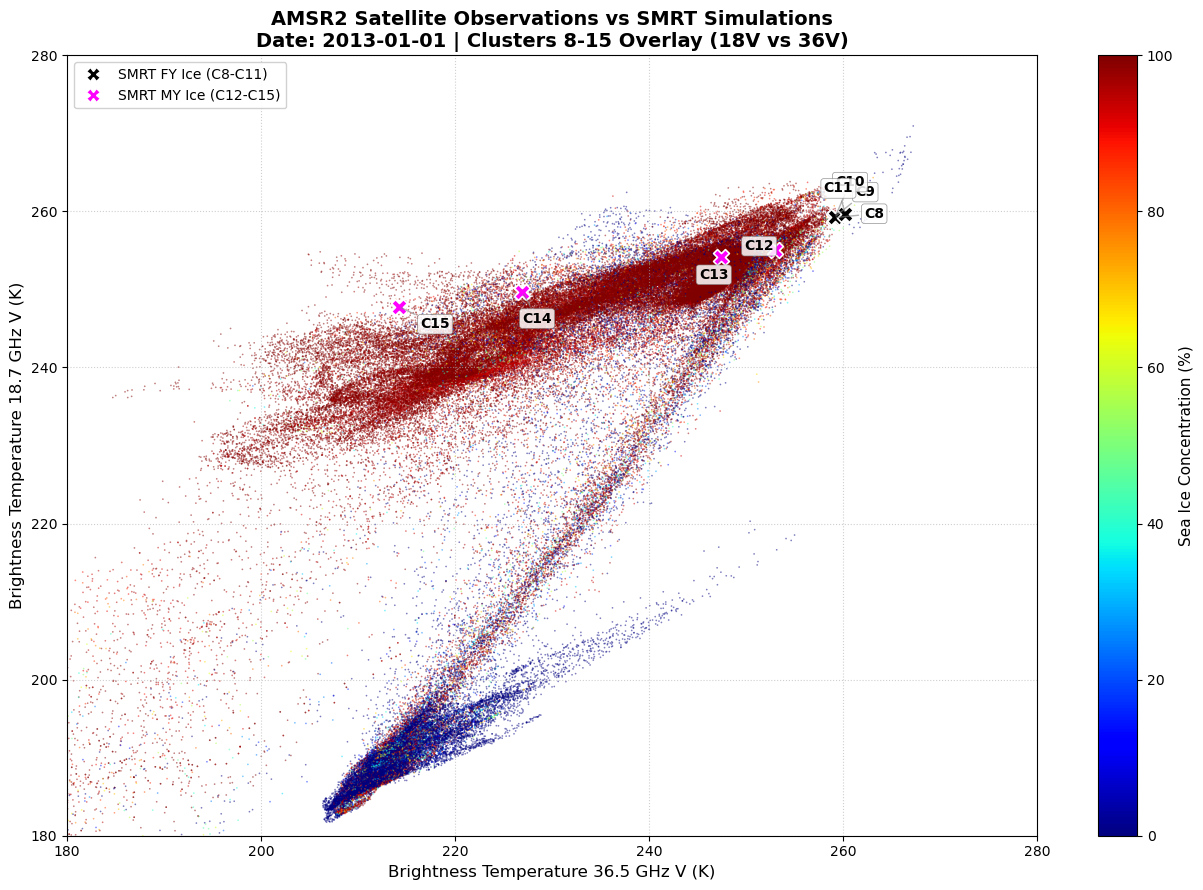

In [15]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# --- CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice) ---
# Cluster 8
snow_8 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_8 = make_ice_column(ice_type="firstyear", thickness=[0.10], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_8 + ice_8 + ocean))

# Cluster 9
snow_9 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_9 = make_ice_column(ice_type="firstyear", thickness=[0.14], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_9 + ice_9 + ocean))

# Cluster 10
snow_10 = make_snowpack(thickness=[0.11], microstructure_model="sticky_hard_spheres", density=[350], temperature=[257.0], radius=[0.16e-3], stickiness=[0.18])
ice_10 = make_ice_column(ice_type="firstyear", thickness=[0.27], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_10 + ice_10 + ocean))

# Cluster 11
snow_11 = make_snowpack(thickness=[0.16], microstructure_model="sticky_hard_spheres", density=[350], temperature=[270.0], radius=[0.16e-3], stickiness=[0.18])
ice_11 = make_ice_column(ice_type="firstyear", thickness=[0.44], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_11 + ice_11 + ocean))

# --- CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow) ---
# Cluster 12
total_depth_12 = 0.01
ws_12 = make_snowpack(thickness=[0.6*total_depth_12], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_12 = make_snowpack(thickness=[0.4*total_depth_12], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_12 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_12 + dh_12 + ice_my_12 + ocean))

# Cluster 13
total_depth_13 = 0.07
ws_13 = make_snowpack(thickness=[0.6*total_depth_13], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_13 = make_snowpack(thickness=[0.4*total_depth_13], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_13 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_13 + dh_13 + ice_my_13 + ocean))

# Cluster 14
total_depth_14 = 0.51
ws_14 = make_snowpack(thickness=[0.6*total_depth_14], density=[350], temperature=[269.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_14 = make_snowpack(thickness=[0.4*total_depth_14], density=[200], temperature=[266.1], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_14 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_14 + dh_14 + ice_my_14 + ocean))

# Cluster 15
total_depth_15 = 0.51
ws_15 = make_snowpack(thickness=[0.6*total_depth_15], density=[350], temperature=[240.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_15 = make_snowpack(thickness=[0.4*total_depth_15], density=[200], temperature=[257.9], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_15 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_15 + dh_15 + ice_my_15 + ocean))

# --- Post-process SMRT Output for 18.7V and 36.5V Channels ---
smrt_v18 = []
smrt_v36 = []

for res in all_results:
    v18_sim = res.TbV(frequency=18.7e9)  
    v36_sim = res.TbV(frequency=36.5e9)
    
    smrt_v18.append(v18_sim)
    smrt_v36.append(v36_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_v18v = []
all_v36v = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v18 = f["Brightness Temperature (res06,18.7GHz,V)"][:, :243].astype(float) * 0.01
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v18 > 50) & (v36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v18_s, v36_s = v18[mask][::stride], v36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v18_final = v18_s[valid_geo][valid_mask]
            v36_final = v36_s[valid_geo][valid_mask]

            all_v18v.extend(v18_final)
            all_v36v.extend(v36_final)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue

# Conversion to numpy arrays for plotting
all_v18v = np.array(all_v18v)
all_v36v = np.array(all_v36v)
all_sic = np.array(all_sic)


# =================================================================
# 3. OVERLAY PLOTTING WITH SMRT LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot (36.5V on X, 18.7V on Y)
sc = plt.scatter(all_v36v, all_v18v, c=all_sic, 
                 s=1.5, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the simulated point marker
    plt.scatter(smrt_v36[i], smrt_v18[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label to fan out text
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_v36[i], smrt_v18[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

# Graph Formatting
plt.xlabel('Brightness Temperature 36.5 GHz V (K)', fontsize=12)
plt.ylabel('Brightness Temperature 18.7 GHz V (K)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | Clusters 8-15 Overlay (18V vs 36V)', 
          fontsize=14, fontweight='bold')

plt.xlim(180, 280)
plt.ylim(180, 280)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

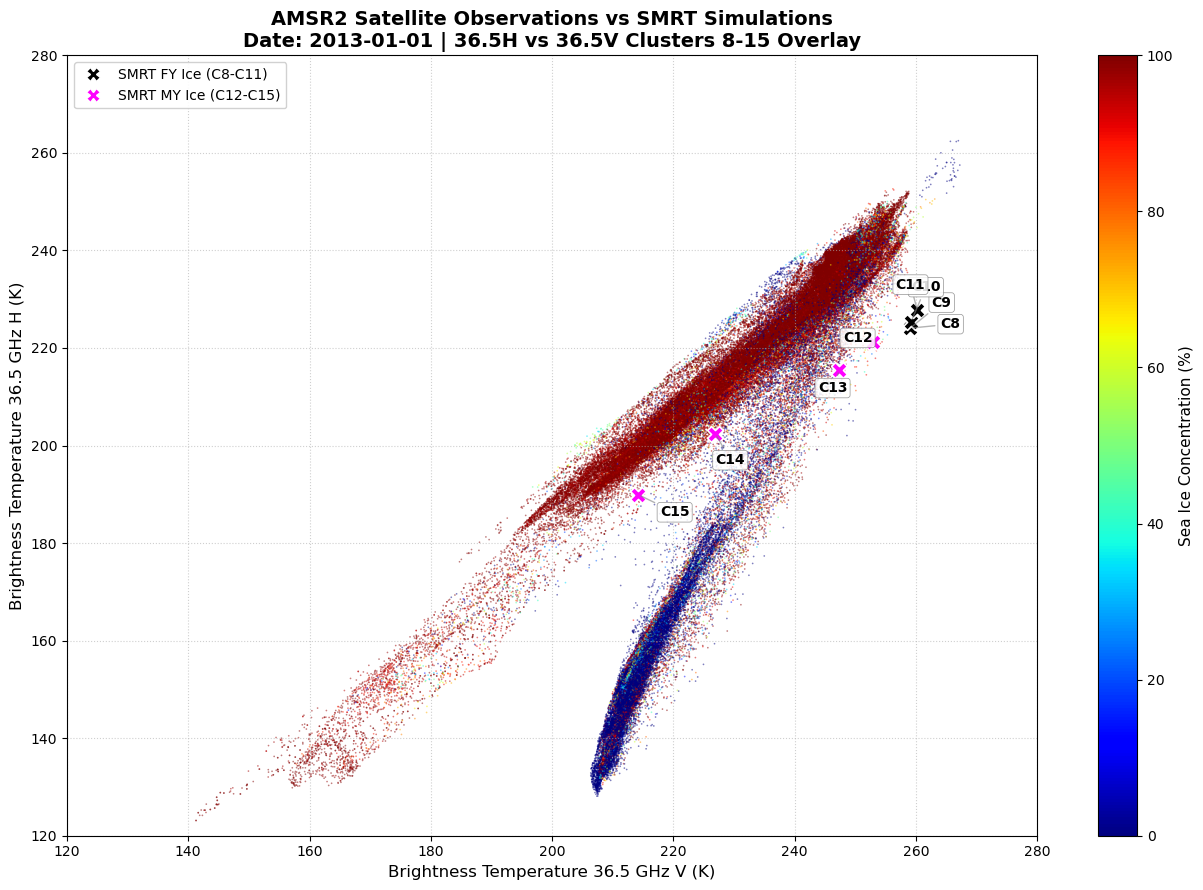

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# --- CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice) ---
# Cluster 8
snow_8 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_8 = make_ice_column(ice_type="firstyear", thickness=[0.10], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_8 + ice_8 + ocean))

# Cluster 9
snow_9 = make_snowpack(thickness=[0.06], microstructure_model="sticky_hard_spheres", density=[350], temperature=[230.0], radius=[0.16e-3], stickiness=[0.18])
ice_9 = make_ice_column(ice_type="firstyear", thickness=[0.14], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_9 + ice_9 + ocean))

# Cluster 10
snow_10 = make_snowpack(thickness=[0.11], microstructure_model="sticky_hard_spheres", density=[350], temperature=[257.0], radius=[0.16e-3], stickiness=[0.18])
ice_10 = make_ice_column(ice_type="firstyear", thickness=[0.27], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_10 + ice_10 + ocean))

# Cluster 11
snow_11 = make_snowpack(thickness=[0.16], microstructure_model="sticky_hard_spheres", density=[350], temperature=[270.0], radius=[0.16e-3], stickiness=[0.18])
ice_11 = make_ice_column(ice_type="firstyear", thickness=[0.44], density=[917], temperature=[265.0], salinity=[10*PSU], brine_volume_fraction=0.11, microstructure_model="sticky_hard_spheres", radius=[0.1e-3], stickiness=[0.2], interface=flat_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, snow_11 + ice_11 + ocean))

# --- CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow) ---
# Cluster 12
total_depth_12 = 0.01
ws_12 = make_snowpack(thickness=[0.6*total_depth_12], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_12 = make_snowpack(thickness=[0.4*total_depth_12], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_12 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_12 + dh_12 + ice_my_12 + ocean))

# Cluster 13
total_depth_13 = 0.07
ws_13 = make_snowpack(thickness=[0.6*total_depth_13], density=[350], temperature=[230.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_13 = make_snowpack(thickness=[0.4*total_depth_13], density=[200], temperature=[255.0], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_13 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_13 + dh_13 + ice_my_13 + ocean))

# Cluster 14
total_depth_14 = 0.51
ws_14 = make_snowpack(thickness=[0.6*total_depth_14], density=[350], temperature=[269.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_14 = make_snowpack(thickness=[0.4*total_depth_14], density=[200], temperature=[266.1], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_14 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_14 + dh_14 + ice_my_14 + ocean))

# Cluster 15
total_depth_15 = 0.51
ws_15 = make_snowpack(thickness=[0.6*total_depth_15], density=[350], temperature=[240.0], microstructure_model="sticky_hard_spheres", radius=[0.16e-3], stickiness=[0.18], interface=flat_interface)
dh_15 = make_snowpack(thickness=[0.4*total_depth_15], density=[200], temperature=[257.9], microstructure_model="sticky_hard_spheres", radius=[0.32e-3], stickiness=[0.10], interface=flat_interface)
ice_my_15 = make_ice_column(ice_type="multiyear", thickness=[2.00], density=[850], temperature=[265.0], salinity=[1.2*PSU], microstructure_model="sticky_hard_spheres", radius=[1e-3], stickiness=[0.2], brine_volume_fraction=0.05, interface=rough_interface, add_water_substrate=False)
all_results.append(model.run(sensor_cimr, ws_15 + dh_15 + ice_my_15 + ocean))

# --- Post-process SMRT Output for 36.5 GHz V vs H ---
smrt_v36 = []
smrt_h36 = []

for res in all_results:
    v36_sim = res.TbV(frequency=36.5e9)
    h36_sim = res.TbH(frequency=36.5e9)
    
    smrt_v36.append(v36_sim)
    smrt_h36.append(h36_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_v36v = []
all_h36h = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01
            h36 = f["Brightness Temperature (res06,36.5GHz,H)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v36 > 50) & (h36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v36_s, h36_s = v36[mask][::stride], h36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v36_final = v36_s[valid_geo][valid_mask]
            h36_final = h36_s[valid_geo][valid_mask]

            all_v36v.extend(v36_final)
            all_h36h.extend(h36_final)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue

# Conversion to numpy arrays
all_v36v = np.array(all_v36v)
all_h36h = np.array(all_h36h)
all_sic = np.array(all_sic)

# =================================================================
# 3. OVERLAY PLOTTING WITH SMART LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot (36.5V on X, 36.5H on Y)
sc = plt.scatter(all_v36v, all_h36h, c=all_sic, 
                 s=1.5, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the point marker
    plt.scatter(smrt_v36[i], smrt_h36[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label to fan them out
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_v36[i], smrt_h36[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

plt.xlabel('Brightness Temperature 36.5 GHz V (K)', fontsize=12)
plt.ylabel('Brightness Temperature 36.5 GHz H (K)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | 36.5H vs 36.5V Clusters 8-15 Overlay', 
          fontsize=14, fontweight='bold')

plt.xlim(120, 280)
plt.ylim(120, 280)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

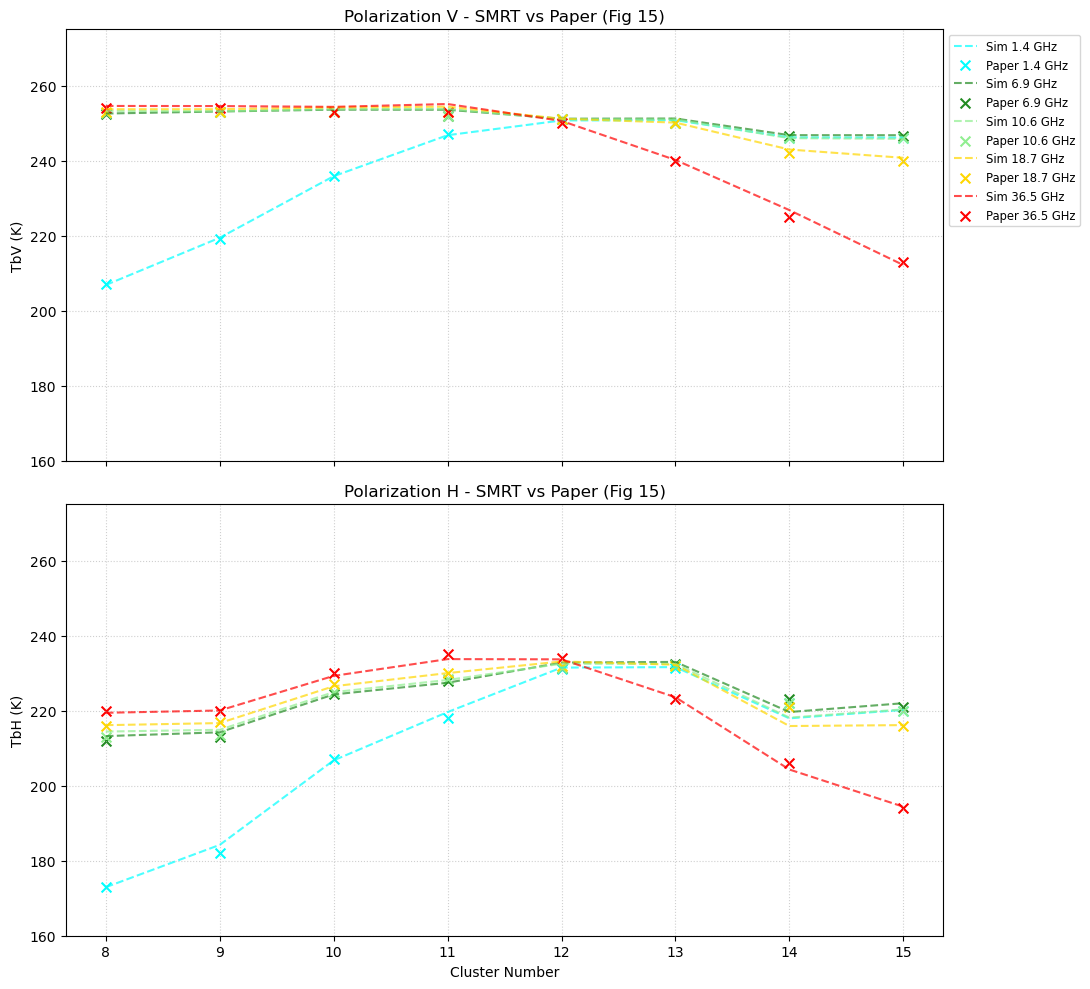


ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS
           1.4V_Err 1.4H_Err 6.9V_Err 6.9H_Err 10.6V_Err 10.6H_Err 18.7V_Err 18.7H_Err 36.5V_Err 36.5H_Err  RMSE_V  RMSE_H RMSE_Total
Cluster                                                                                                                              
Cluster 08   -0.2 K   -0.1 K   +0.0 K   +1.2 K    +0.5 K    +1.4 K    +0.7 K    +0.1 K    +0.6 K    -0.6 K  0.46 K  0.88 K     0.71 K
Cluster 09   +0.4 K   +2.2 K   +0.1 K   +1.2 K    +0.2 K    +1.4 K    +0.7 K    -0.3 K    +0.5 K    +0.1 K  0.45 K  1.31 K     0.98 K
Cluster 10   -0.2 K   -0.2 K   +0.6 K   -0.2 K    +0.7 K    -0.0 K    +1.2 K    -0.5 K    +1.3 K    -0.7 K  0.90 K  0.41 K     0.70 K
Cluster 11   -0.2 K   +1.6 K   +1.6 K   -0.5 K    +1.8 K    -0.3 K    +1.4 K    +0.0 K    +2.1 K    -1.2 K  1.55 K  0.96 K     1.29 K
Cluster 12   -0.3 K   +0.5 K   +0.2 K   +1.3 K    +0.1 K    +1.0 K    +0.2 K    +1.1 K    +0.6 K    -0.3 K  0.31 K  0.94 K     0.70 K
Cluster 13 

In [21]:
#correct cluster from Clément Soriot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

# Definition of interfaces according to the paper methodology
rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")

# --- Permanent Substrate (Ocean) ---
ocean = make_water_body(temperature=272, salinity=30 * PSU)

# List to store results for each cluster
all_results = []
theta = [55]
frequency_cimr = [1.4e9,6.9e9,10.6e9,18.7e9,36.5e9,89e9]
cimr = sensor_list.passive(frequency_cimr, theta,polarization=['V','H'])
water_temperature=272
water_salinity=30*PSU
salinity_fy=10*PSU
interface_rought = make_interface("geometrical_optics", mean_square_slope=0.1)
interface_flat = None
dh_my=0.7
dh_fy=0.1
mean_snowdepth=0.35
thin_ice = 0.4
thick_ice=2
# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================
"""
Cluster 8
Sea Ice Type : Firstyear
SIT = 10cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat

Sous couche oui density=400, thickness 0.1
"""
cluster_8 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.1,],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-4,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=salinity_fy,
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_8))

"""
Cluster 9
Sea Ice Type : Firstyear
SIT = 15cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat
"""
cluster_9 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.15],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-4,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=salinity_fy,
                          add_water_substrate='ocean',
                          water_temperature=272,
                          water_salinity=30*PSU,
                          interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_9))

# Cluster 10
"""
Cluster 10
Sea Ice Type : Firstyear

SIT = 25cm
SIC 100%
Snowdepth = 10cm

Interface glace/air flat
"""

cluster_10 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.1],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.25],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-4,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=salinity_fy,
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_10))

"""
Cluster 11
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 10cm
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""

cluster_11 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.10],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[260],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.4],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-4,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=salinity_fy,
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_11))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

"""
Cluster 12
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 15cm
Interface glace/neige rugueuse

Sous couche oui density=400, thickness 10cm
"""
snowdepth=0.15
cluster_12 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
               make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='firstyear', thickness=[1],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-4,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=salinity_fy,
                          density=[917],
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_rought)]

all_results.append(model.run(sensor_cimr, cluster_12))

"""
Cluster 13
Sea Ice Type : Multiyear

SIT = 1m
SIC 100%
Snowdepth = 20 cm
SNow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
snowdepth=0.2

cluster_13 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[0.001],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
               make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.17, # Conservé (déjà indiqué à 0.17)
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[1],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-3,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=1.2*PSU,
                          density=[917],
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_13))

# Cluster 14
"""
Cluster 14
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 20 cm
Snow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
dh_temp = 0.25
snowdepth=0.30

cluster_14 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            # make_snowpack(thickness=[0.01],
            #                microstructure_model='sticky_hard_spheres',
            #                temperature=[230],
            #                radius=[1e-4],
            #                density=[200],
            #                stickiness=0.2,
            #                liquid_water=0,
            #                salinity=0*PSU,
            #                interface=interface_flat)+
             make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                           microstructure_model='sticky_hard_spheres',
                           temperature=[230],
                           radius=[3/917/20],
                           density=[350],
                           stickiness=0.2,
                           liquid_water=0,
                           salinity=0*PSU,
                           interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*dh_temp], #DH
                         microstructure_model='sticky_hard_spheres',
                         temperature=[260],
                         radius=[3/917/10],
                         density=[200],
                         stickiness=0.095, # Conservé (déjà indiqué à 0.095)
                         liquid_water=0,
                         salinity=0,
                         interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[2],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-3,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=1.2*PSU,
                          density=[917], #350
                          add_water_substrate='ocean',
                          water_temperature=water_temperature,
                          water_salinity=water_salinity,
                          interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_14))

# Cluster 15
"""
Cluster 15
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 35cm mean on arctic
Snow composition: 40% Windpack + 60% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""
dh_temp = 0.4
snowdepth=0.40

cluster_15 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
               make_snowpack(thickness=[snowdepth*dh_temp],
                          microstructure_model='sticky_hard_spheres',
                          temperature=260,
                          radius=[3/917/10],
                          density=[200],
                          stickiness=0.1, # Conservé (déjà indiqué à 0.1)
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[4],
                          temperature=260,
                          microstructure_model='sticky_hard_spheres',
                          radius=1e-3,
                          stickiness=0.2, # Stickiness ajoutée ici
                          brine_inclusion_shape='spheres',
                          brine_volume_fraction=0.11,
                          salinity=1*PSU,
                          density=[917],
                          add_water_substrate='ocean',
                          water_temperature=272,
                          water_salinity=30*PSU,
                          interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_15))


# =================================================================
# Data from the paper (Figure 15)
# =================================================================
data_paper_v = {
    '1.4':  [207.0, 219.0, 236.0, 247.0, 251.0, 250.0, 246.0, 246.0],
    '6.9':  [252.5, 253.0, 253.0, 252.0, 251.0, 250.0, 246.5, 246.5],
    '10.6': [252.8, 253.0, 253.0, 252.0, 251.0, 250.0, 246.0, 246.0],
    '18.7': [253.0, 253.0, 253.0, 253.0, 251.0, 250.0, 242.0, 240.0],
    '36.5': [254.0, 254.0, 253.0, 253.0, 250.0, 240.0, 225.0, 213.0]
}

data_paper_h = {
    '1.4':  [173.0, 182.0, 207.0, 218.0, 231.0, 231.5, 222.0, 220.0],
    '6.9':  [212.0, 213.0, 224.5, 228.0, 231.5, 232.5, 223.0, 221.0],
    '10.6': [213.0, 213.5, 225.0, 228.5, 231.5, 232.2, 222.0, 220.0],
    '18.7': [216.0, 217.0, 227.0, 230.0, 232.0, 232.0, 221.0, 216.0],
    '36.5': [220.0, 220.0, 230.0, 235.0, 234.0, 223.0, 206.0, 194.0]
}


# =================================================================
# PLOTTING RESULTS (V and H Polarizations)
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
colors = ['cyan', 'forestgreen', 'lightgreen', 'gold', 'red']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}


fig, axes = plt.subplots(2, 1, figsize=(11, 10), sharex=True)


for p_idx, pol in enumerate(pols):
    ax = axes[p_idx]
    paper_dict = data_papers[pol]
    
    for i, f in enumerate(freqs):
        tb_list = []
        for res in all_results:
            val = res.data.sel(polarization=pol).sel(frequency=f, method='nearest')
            tb_list.append(val.item())
        
        # Plot Simulation
        ax.plot(clusters, tb_list, '--', color=colors[i], alpha=0.7, label=f'Sim {freq_keys[i]} GHz')
        
        # Plot Paper Data
        ax.scatter(clusters, paper_dict[freq_keys[i]], marker='x', s=50, 
                   color=colors[i], linewidths=1.5, label=f'Paper {freq_keys[i]} GHz')

    ax.set_ylabel(f'Tb{pol} (K)')
    ax.set_title(f'Polarization {pol} - SMRT vs Paper (Fig 15)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_ylim(160, 275)
    if p_idx == 0:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

plt.xlabel('Cluster Number')
plt.tight_layout()
plt.show()


# =================================================================
# ERROR CALCULATION & TABLE GENERATION
# =================================================================
clusters = np.arange(8, 16)
freqs = [1.4e9, 6.9e9, 10.6e9, 18.7e9, 36.5e9]
freq_keys = ['1.4', '6.9', '10.6', '18.7', '36.5']
pols = ['V', 'H']
data_papers = {'V': data_paper_v, 'H': data_paper_h}

rows_list = []


for idx, cluster_id in enumerate(clusters):
    res = all_results[idx]
    row_data = {'Cluster': f"Cluster {cluster_id:02d}"}
    
    all_squared_errors = []
    v_squared_errors = []
    h_squared_errors = []
    
    for f_idx, f in enumerate(freqs):
        f_key = freq_keys[f_idx]
        for pol in pols:
            # Retrieve SMRT simulation value
            tb_sim = res.data.sel(polarization=pol).sel(frequency=f, method='nearest').item()
            # Retrieve paper target value (aligning indices from 0 to 7)
            tb_paper = data_papers[pol][f_key][idx]
            
            # Calculate individual error (Difference in Kelvin)
            error = tb_sim - tb_paper
            row_data[f"{f_key}{pol}_Err"] = f"{error:+.1f} K"
            
            # Store values for aggregate RMSE calculations
            sq_err = error ** 2
            all_squared_errors.append(sq_err)
            if pol == 'V':
                v_squared_errors.append(sq_err)
            else:
                h_squared_errors.append(sq_err)
                
    # Calculate RMSE metrics
    row_data['RMSE_V'] = f"{np.sqrt(np.mean(v_squared_errors)):.2f} K"
    row_data['RMSE_H'] = f"{np.sqrt(np.mean(h_squared_errors)):.2f} K"
    row_data['RMSE_Total'] = f"{np.sqrt(np.mean(all_squared_errors)):.2f} K"
    
    rows_list.append(row_data)


# Create and display the results table using Pandas
df_errors = pd.DataFrame(rows_list).set_index('Cluster')


print("\n" + "="*80)
print("ERROR TABLE BY CHANNEL AND GLOBAL RMSE STATISTICS")
print("="*80)
# Force display of all columns in the console output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_errors)
print("="*80 + "\n")

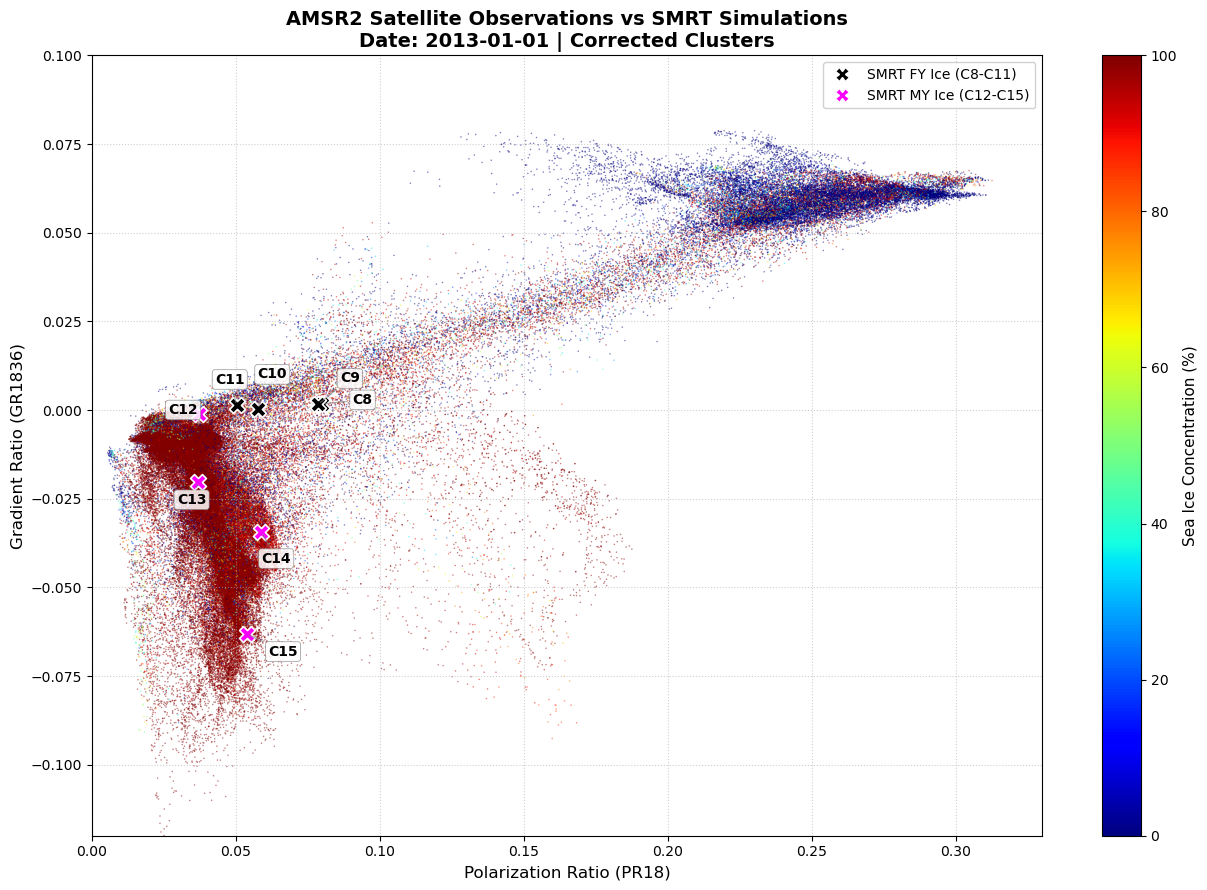

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# List to store results for each cluster
all_results = []
theta = [55]
frequency_cimr = [1.4e9,6.9e9,10.6e9,18.7e9,36.5e9,89e9]
cimr = sensor_list.passive(frequency_cimr, theta,polarization=['V','H'])
water_temperature=272
water_salinity=30*PSU
salinity_fy=10*PSU
interface_rought = make_interface("geometrical_optics", mean_square_slope=0.1)
interface_flat = None
dh_my=0.7
dh_fy=0.1
mean_snowdepth=0.35
thin_ice = 0.4
thick_ice=2
# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================
"""
Cluster 8
Sea Ice Type : Firstyear
SIT = 10cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat

Sous couche oui density=400, thickness 0.1
"""
cluster_8 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.1,],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_8))

"""
Cluster 9
Sea Ice Type : Firstyear
SIT = 15cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat
"""
cluster_9 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.15],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_9))

# Cluster 10
"""
Cluster 10
Sea Ice Type : Firstyear

SIT = 25cm
SIC 100%
Snowdepth = 10cm

Interface glace/air flat
"""

cluster_10 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.1],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.25],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_10))

"""
Cluster 11
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 10cm
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""

cluster_11 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.10],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[260],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_11))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

"""
Cluster 12
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 15cm
Interface glace/neige rugueuse

Sous couche oui density=400, thickness 10cm
"""
snowdepth=0.15
cluster_12 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='firstyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]

all_results.append(model.run(sensor_cimr, cluster_12))

"""
Cluster 13
Sea Ice Type : Multiyear

SIT = 1m
SIC 100%
Snowdepth = 20 cm
SNow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
snowdepth=0.2

cluster_13 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[0.001],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.17,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_13))

# Cluster 14
"""
Cluster 14
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 20 cm
Snow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
dh_temp = 0.25
snowdepth=0.30

cluster_14 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            # make_snowpack(thickness=[0.01],
            #               microstructure_model='sticky_hard_spheres',
            #               temperature=[230],
            #               radius=[1e-4],
            #               density=[200],
            #               stickiness=0.2,
            #               liquid_water=0,
            #               salinity=0*PSU,
            #               interface=interface_flat)+
            make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                           microstructure_model='sticky_hard_spheres',
                           temperature=[230],
                           radius=[3/917/20],
                           density=[350],
                           stickiness=0.2,
                           liquid_water=0,
                           salinity=0*PSU,
                           interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*dh_temp], #DH
                         microstructure_model='sticky_hard_spheres',
                         temperature=[260],
                         radius=[3/917/10],
                         density=[200],
                         stickiness=0.095,
                         liquid_water=0,
                         salinity=0,
                         interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[2],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917], #350
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_14))

# Cluster 15
"""
Cluster 15
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 35cm mean on arctic
Snow composition: 40% Windpack + 60% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""
dh_temp = 0.4
snowdepth=0.40

cluster_15 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth*dh_temp],
                          microstructure_model='sticky_hard_spheres',
                          temperature=260,
                          radius=[3/917/10],
                          density=[200],
                          stickiness=0.1,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_15))


# --- Post-process SMRT Output for PR18 and GR1836 ---
smrt_pr = []
smrt_gr = []

for res in all_results:
    v18_sim = res.TbV(frequency=18.7e9)  
    h18_sim = res.TbH(frequency=18.7e9)  
    v36_sim = res.TbV(frequency=36.5e9)
    
    pr_sim = (v18_sim - h18_sim) / (v18_sim + h18_sim)
    gr_sim = (v36_sim - v18_sim) / (v36_sim + v18_sim)
    
    smrt_pr.append(pr_sim)
    smrt_gr.append(gr_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2_L1R_2013\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_pr = []
all_gr = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v18 = f["Brightness Temperature (res06,18.7GHz,V)"][:, :243].astype(float) * 0.01
            h18 = f["Brightness Temperature (res06,18.7GHz,H)"][:, :243].astype(float) * 0.01
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v18 > 50) & (h18 > 50) & (v36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v18_s, h18_s, v36_s = v18[mask][::stride], h18[mask][::stride], v36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v18_final = v18_s[valid_geo][valid_mask]
            h18_final = h18_s[valid_geo][valid_mask]
            v36_final = v36_s[valid_geo][valid_mask]

            pr = (v18_final - h18_final) / (v18_final + h18_final)
            gr = (v36_final - v18_final) / (v36_final + v18_final)

            all_pr.extend(pr)
            all_gr.extend(gr)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue


# =================================================================
# 3. OVERLAY PLOTTING WITH SMART LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot
sc = plt.scatter(all_pr, all_gr, c=all_sic, 
                 s=1.2, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the point marker
    plt.scatter(smrt_pr[i], smrt_gr[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label
    # This fans out the text markers even if the underlying coordinates are identical
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_pr[i], smrt_gr[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

plt.xlabel('Polarization Ratio (PR18)', fontsize=12)
plt.ylabel('Gradient Ratio (GR1836)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | Corrected Clusters', 
          fontsize=14, fontweight='bold')

plt.xlim(0, 0.33)
plt.ylim(-0.12, 0.10)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes (Using fixed Line2D import)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

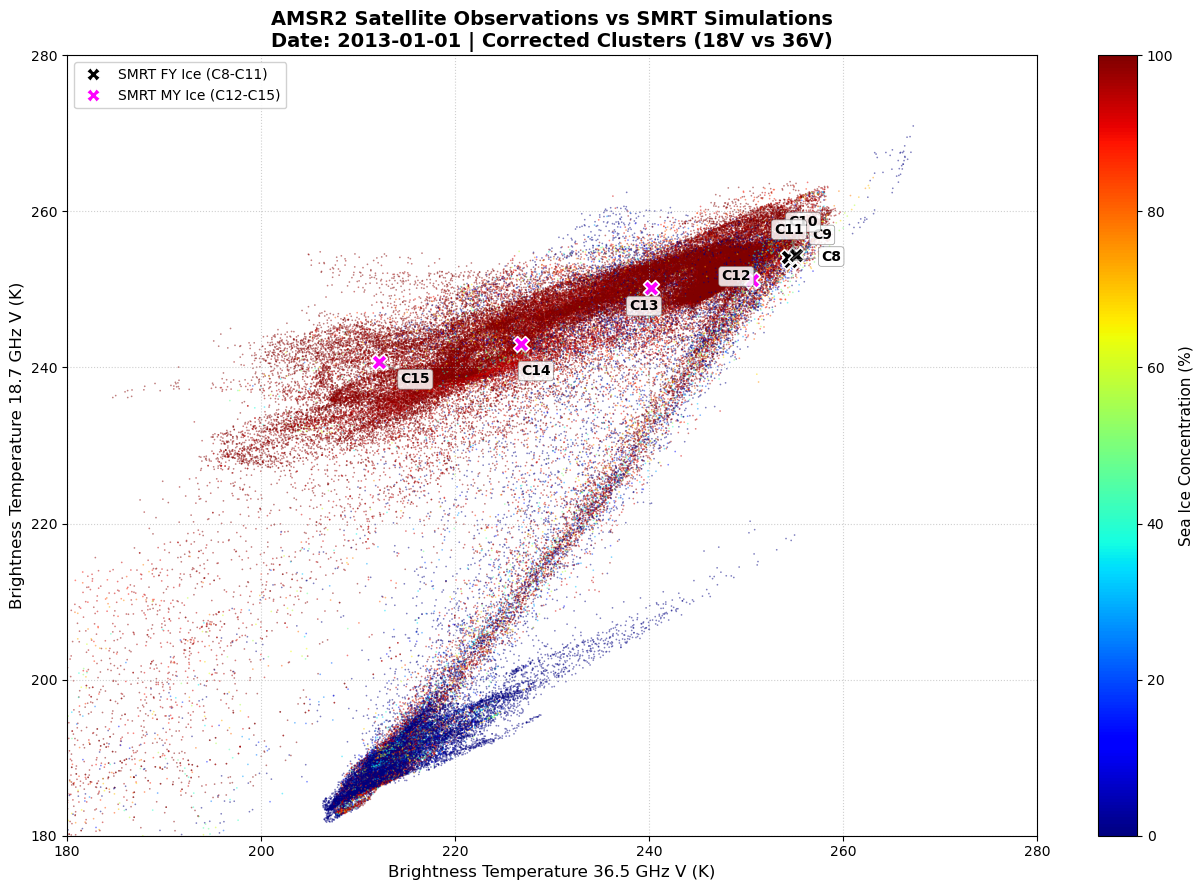

In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# List to store results for each cluster
all_results = []
theta = [55]
frequency_cimr = [1.4e9,6.9e9,10.6e9,18.7e9,36.5e9,89e9]
cimr = sensor_list.passive(frequency_cimr, theta,polarization=['V','H'])
water_temperature=272
water_salinity=30*PSU
salinity_fy=10*PSU
interface_rought = make_interface("geometrical_optics", mean_square_slope=0.1)
interface_flat = None
dh_my=0.7
dh_fy=0.1
mean_snowdepth=0.35
thin_ice = 0.4
thick_ice=2
# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================
"""
Cluster 8
Sea Ice Type : Firstyear
SIT = 10cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat

Sous couche oui density=400, thickness 0.1
"""
cluster_8 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.1,],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_8))

"""
Cluster 9
Sea Ice Type : Firstyear
SIT = 15cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat
"""
cluster_9 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.15],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_9))

# Cluster 10
"""
Cluster 10
Sea Ice Type : Firstyear

SIT = 25cm
SIC 100%
Snowdepth = 10cm

Interface glace/air flat
"""

cluster_10 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.1],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.25],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_10))

"""
Cluster 11
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 10cm
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""

cluster_11 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.10],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[260],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_11))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

"""
Cluster 12
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 15cm
Interface glace/neige rugueuse

Sous couche oui density=400, thickness 10cm
"""
snowdepth=0.15
cluster_12 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='firstyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]

all_results.append(model.run(sensor_cimr, cluster_12))

"""
Cluster 13
Sea Ice Type : Multiyear

SIT = 1m
SIC 100%
Snowdepth = 20 cm
SNow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
snowdepth=0.2

cluster_13 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[0.001],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.17,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_13))

# Cluster 14
"""
Cluster 14
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 20 cm
Snow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
dh_temp = 0.25
snowdepth=0.30

cluster_14 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            # make_snowpack(thickness=[0.01],
            #               microstructure_model='sticky_hard_spheres',
            #               temperature=[230],
            #               radius=[1e-4],
            #               density=[200],
            #               stickiness=0.2,
            #               liquid_water=0,
            #               salinity=0*PSU,
            #               interface=interface_flat)+
            make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                           microstructure_model='sticky_hard_spheres',
                           temperature=[230],
                           radius=[3/917/20],
                           density=[350],
                           stickiness=0.2,
                           liquid_water=0,
                           salinity=0*PSU,
                           interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*dh_temp], #DH
                         microstructure_model='sticky_hard_spheres',
                         temperature=[260],
                         radius=[3/917/10],
                         density=[200],
                         stickiness=0.095,
                         liquid_water=0,
                         salinity=0,
                         interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[2],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917], #350
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_14))

# Cluster 15
"""
Cluster 15
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 35cm mean on arctic
Snow composition: 40% Windpack + 60% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""
dh_temp = 0.4
snowdepth=0.40

cluster_15 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth*dh_temp],
                          microstructure_model='sticky_hard_spheres',
                          temperature=260,
                          radius=[3/917/10],
                          density=[200],
                          stickiness=0.1,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_15))


# --- Post-process SMRT Output for 18.7V and 36.5V Channels ---
smrt_v18 = []
smrt_v36 = []

for res in all_results:
    v18_sim = res.TbV(frequency=18.7e9)  
    v36_sim = res.TbV(frequency=36.5e9)
    
    smrt_v18.append(v18_sim)
    smrt_v36.append(v36_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2_L1R_2013\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_v18v = []
all_v36v = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v18 = f["Brightness Temperature (res06,18.7GHz,V)"][:, :243].astype(float) * 0.01
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v18 > 50) & (v36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v18_s, v36_s = v18[mask][::stride], v36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v18_final = v18_s[valid_geo][valid_mask]
            v36_final = v36_s[valid_geo][valid_mask]

            all_v18v.extend(v18_final)
            all_v36v.extend(v36_final)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue

# Conversion to numpy arrays for plotting
all_v18v = np.array(all_v18v)
all_v36v = np.array(all_v36v)
all_sic = np.array(all_sic)


# =================================================================
# 3. OVERLAY PLOTTING WITH SMRT LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot (36.5V on X, 18.7V on Y)
sc = plt.scatter(all_v36v, all_v18v, c=all_sic, 
                 s=1.5, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the simulated point marker
    plt.scatter(smrt_v36[i], smrt_v18[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label to fan out text
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_v36[i], smrt_v18[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

# Graph Formatting
plt.xlabel('Brightness Temperature 36.5 GHz V (K)', fontsize=12)
plt.ylabel('Brightness Temperature 18.7 GHz V (K)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | Corrected Clusters (18V vs 36V)', 
          fontsize=14, fontweight='bold')

plt.xlim(180, 280)
plt.ylim(180, 280)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

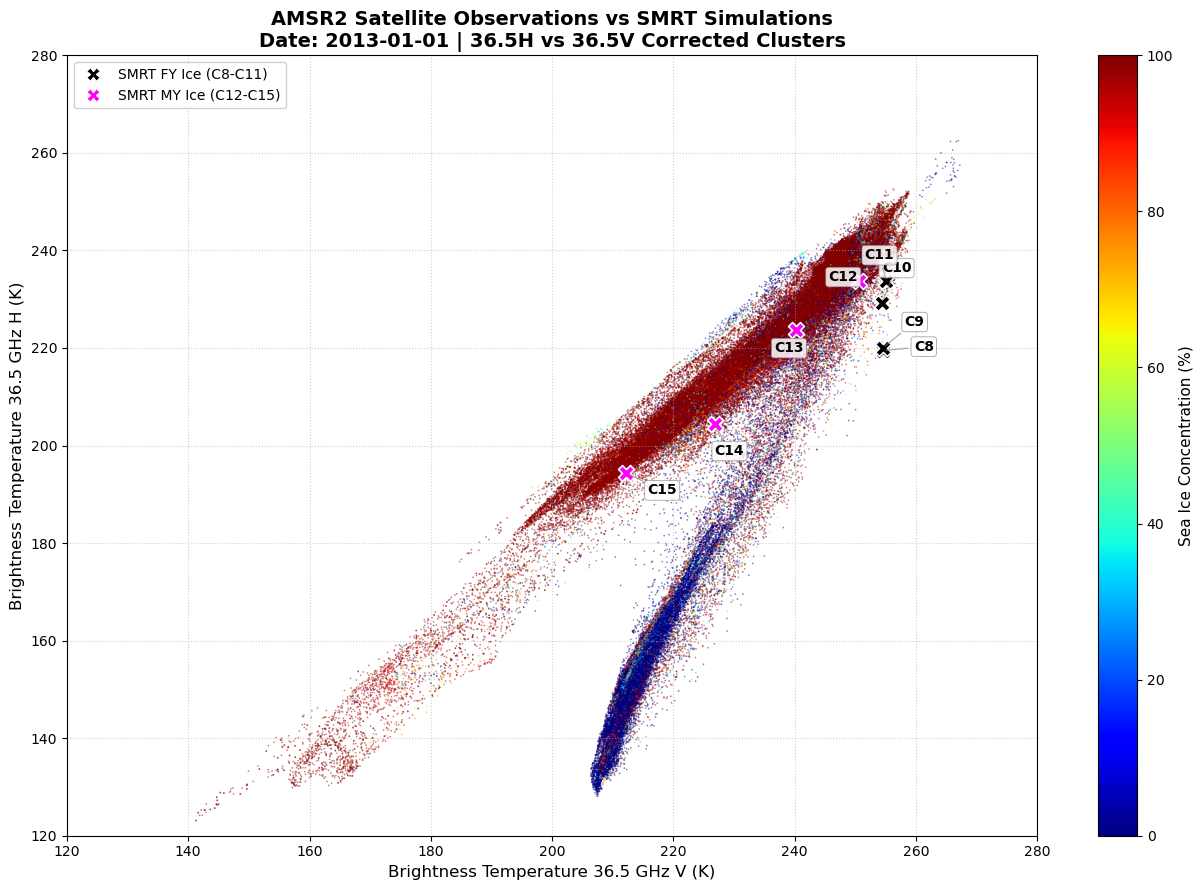

In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from netCDF4 import Dataset
from pyproj import Proj
from scipy.ndimage import maximum_filter

# SMRT Imports
from smrt import make_model, sensor_list, PSU, make_snowpack, make_water_body
from smrt.inputs.make_medium import make_ice_column
from smrt.core.interface import make_interface

# =================================================================
# 1. SMRT SIMULATIONS
# =================================================================

# --- Model and Sensor Configuration ---
sensor_cimr = sensor_list.cimr()
model = make_model("iba", "dort", rtsolver_options=dict(n_max_stream=128))

rough_interface = make_interface("geometrical_optics", mean_square_slope=0.1)
flat_interface = make_interface("flat")
ocean = make_water_body(temperature=272, salinity=30 * PSU)

all_results = []
cluster_labels = list(range(8, 16))

# List to store results for each cluster
all_results = []
theta = [55]
frequency_cimr = [1.4e9,6.9e9,10.6e9,18.7e9,36.5e9,89e9]
cimr = sensor_list.passive(frequency_cimr, theta,polarization=['V','H'])
water_temperature=272
water_salinity=30*PSU
salinity_fy=10*PSU
interface_rought = make_interface("geometrical_optics", mean_square_slope=0.1)
interface_flat = None
dh_my=0.7
dh_fy=0.1
mean_snowdepth=0.35
thin_ice = 0.4
thick_ice=2
# =================================================================
# CLUSTERS 8 to 11: Ice Growth Phase (First-Year Ice)
# =================================================================
"""
Cluster 8
Sea Ice Type : Firstyear
SIT = 10cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat

Sous couche oui density=400, thickness 0.1
"""
cluster_8 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.1,],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_8))

"""
Cluster 9
Sea Ice Type : Firstyear
SIT = 15cm
SIC 100%
Snowdepth = 0cm
Interface glace/air flat
"""
cluster_9 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
                   make_ice_column(ice_type='firstyear', thickness=[0.15],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_9))

# Cluster 10
"""
Cluster 10
Sea Ice Type : Firstyear

SIT = 25cm
SIC 100%
Snowdepth = 10cm

Interface glace/air flat
"""

cluster_10 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.1],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[240],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.25],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]

all_results.append(model.run(sensor_cimr, cluster_10))

"""
Cluster 11
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 10cm
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""

cluster_11 = [make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_snowpack(thickness=[0.10],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[260],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
             make_ice_column(ice_type='firstyear', thickness=[0.4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_flat)]


all_results.append(model.run(sensor_cimr, cluster_11))


# =================================================================
# CLUSTERS 12 to 15: Snow Accumulation Phase (Multi-year ice + snow)
# =================================================================

"""
Cluster 12
Sea Ice Type : Firstyear

SIT = 1m
SIC 100%
Snowdepth = 15cm
Interface glace/neige rugueuse

Sous couche oui density=400, thickness 10cm
"""
snowdepth=0.15
cluster_12 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='firstyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-4,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=salinity_fy,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]

all_results.append(model.run(sensor_cimr, cluster_12))

"""
Cluster 13
Sea Ice Type : Multiyear

SIT = 1m
SIC 100%
Snowdepth = 20 cm
SNow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
snowdepth=0.2

cluster_13 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[0.001],
                          density=[100],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.17,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[1],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_13))

# Cluster 14
"""
Cluster 14
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 20 cm
Snow composition: 70% Windpack + 30% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 5cm
"""
dh_temp = 0.25
snowdepth=0.30

cluster_14 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[150],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            # make_snowpack(thickness=[0.01],
            #               microstructure_model='sticky_hard_spheres',
            #               temperature=[230],
            #               radius=[1e-4],
            #               density=[200],
            #               stickiness=0.2,
            #               liquid_water=0,
            #               salinity=0*PSU,
            #               interface=interface_flat)+
            make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                           microstructure_model='sticky_hard_spheres',
                           temperature=[230],
                           radius=[3/917/20],
                           density=[350],
                           stickiness=0.2,
                           liquid_water=0,
                           salinity=0*PSU,
                           interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*dh_temp], #DH
                         microstructure_model='sticky_hard_spheres',
                         temperature=[260],
                         radius=[3/917/10],
                         density=[200],
                         stickiness=0.095,
                         liquid_water=0,
                         salinity=0,
                         interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[2],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1.2*PSU,
                         density=[917], #350
                         add_water_substrate='ocean',
                         water_temperature=water_temperature,
                         water_salinity=water_salinity,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_14))

# Cluster 15
"""
Cluster 15
Sea Ice Type : Multiyear

SIT = 2m
SIC 100%
Snowdepth = 35cm mean on arctic
Snow composition: 40% Windpack + 60% DH
Interface glace/neige rugueuse

Sous couche oui density=300, thickness 10cm
"""
dh_temp = 0.4
snowdepth=0.40

cluster_15 =[make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[100],
                          stickiness=0.2,
                          salinity=0*PSU,
                          interface=interface_flat)+
            make_snowpack(thickness=[0.01],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[1e-4],
                          density=[200],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_snowpack(thickness=[snowdepth*(1-dh_temp)],
                          microstructure_model='sticky_hard_spheres',
                          temperature=[230],
                          radius=[3/917/20],
                          density=[350],
                          stickiness=0.2,
                          liquid_water=0,
                          salinity=0*PSU,
                          interface=interface_flat)+
              make_snowpack(thickness=[snowdepth*dh_temp],
                          microstructure_model='sticky_hard_spheres',
                          temperature=260,
                          radius=[3/917/10],
                          density=[200],
                          stickiness=0.1,
                          salinity=0*PSU,
                          interface=interface_flat)+
           make_ice_column(ice_type='multiyear', thickness=[4],
                         temperature=260,
                         microstructure_model='sticky_hard_spheres',
                         radius=1e-3,
                         brine_inclusion_shape='spheres',
                         brine_volume_fraction=0.11,
                         salinity=1*PSU,
                         density=[917],
                         add_water_substrate='ocean',
                         water_temperature=272,
                         water_salinity=30*PSU,
                         interface=interface_rought)]
all_results.append(model.run(sensor_cimr, cluster_15))


# --- Post-process SMRT Output for 36.5 GHz V vs H ---
smrt_v36 = []
smrt_h36 = []

for res in all_results:
    v36_sim = res.TbV(frequency=36.5e9)
    h36_sim = res.TbH(frequency=36.5e9)
    
    smrt_v36.append(v36_sim)
    smrt_h36.append(h36_sim)


# =================================================================
# 2. AMSR2 SATELLITE OBSERVATIONS
# =================================================================

month = "01"
day_str = "01"
stride = 10

grid_limit = 5400000
res_grid = 12500
grid_size = 864

ease_proj = Proj("+proj=laea +lat_0=90 +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m")

amsr_folder = rf"C:\AMSR2_L1R_2013\L1R\2013\{month}"
osisaf_folder = rf"C:\OSI_SAF\sea_ice_concentration\cdr-v3p0\2013\{month}"

all_v36v = []
all_h36h = []
all_sic = []

# --- Process OSI SAF Grid ---
osi_pattern = os.path.join(osisaf_folder, f"ice_conc_nh_ease2-250_cdr-v3p0_201301{day_str}1200.nc")
osi_files = glob.glob(osi_pattern)

if not osi_files:
    raise FileNotFoundError(f"Target OSI SAF file not found for day {day_str}.")

with Dataset(osi_files[0], 'r') as nc:
    d = nc.variables['ice_conc'][0, :, :]
    flags = nc.variables['status_flag'][0, :, :]
    
    invalid_mask = (flags != 0) & (flags != 4) & (flags != 20)
    strict_mask = invalid_mask | d.mask
    land_mask_buffer = maximum_filter(strict_mask, size=6)
    d_clean = np.where(land_mask_buffer, np.nan, d.astype(float))
    grid_sic = np.repeat(np.repeat(d_clean, 2, axis=0), 2, axis=1)

# --- Process AMSR2 Swaths ---
amsr_day_files = glob.glob(os.path.join(amsr_folder, f"*201301{day_str}*"))

for f_path in amsr_day_files:
    try:
        with h5py.File(f_path, 'r') as f:
            lat = f['Latitude of Observation Point for 89A'][:, :243]
            lon = f['Longitude of Observation Point for 89A'][:, :243]
            
            v36 = f["Brightness Temperature (res06,36.5GHz,V)"][:, :243].astype(float) * 0.01
            h36 = f["Brightness Temperature (res06,36.5GHz,H)"][:, :243].astype(float) * 0.01

            mask = (lat > 30) & (v36 > 50) & (h36 > 50)
            
            lat_s, lon_s = lat[mask][::stride], lon[mask][::stride]
            v36_s, h36_s = v36[mask][::stride], h36[mask][::stride]

            x, y = ease_proj(lon_s, lat_s)
            
            x_idx = ((x + grid_limit) / res_grid).astype(int)
            y_idx = ((grid_limit - y) / res_grid).astype(int)

            valid_geo = (x_idx >= 0) & (x_idx < grid_size) & (y_idx >= 0) & (y_idx < grid_size)
            
            sic_at_pts = grid_sic[y_idx[valid_geo], x_idx[valid_geo]]
            valid_mask = ~np.isnan(sic_at_pts)
            
            v36_final = v36_s[valid_geo][valid_mask]
            h36_final = h36_s[valid_geo][valid_mask]

            all_v36v.extend(v36_final)
            all_h36h.extend(h36_final)
            all_sic.extend(sic_at_pts[valid_mask])

    except Exception as e:
        continue

# Conversion to numpy arrays
all_v36v = np.array(all_v36v)
all_h36h = np.array(all_h36h)
all_sic = np.array(all_sic)

# =================================================================
# 3. OVERLAY PLOTTING WITH SMART LABELS FANNING
# =================================================================

plt.figure(figsize=(13, 9), facecolor='white')

# Background Satellite Scatter Plot (36.5V on X, 36.5H on Y)
sc = plt.scatter(all_v36v, all_h36h, c=all_sic, 
                 s=1.5, cmap='jet', alpha=0.5, edgecolors='none', 
                 vmin=0, vmax=100, label='AMSR2 Observations')

# Overlay SMRT Simulated Cluster Points
for i, cluster in enumerate(cluster_labels):
    marker_style = 'X'
    marker_color = 'black' if cluster <= 11 else 'magenta'
    
    # Plot the point marker
    plt.scatter(smrt_v36[i], smrt_h36[i], 
                color=marker_color, marker=marker_style, s=130, 
                edgecolors='white', linewidths=1.2, zorder=5)
    
    # Calculate a unique directional offset for each cluster label to fan them out
    angle = i * (2 * np.pi / len(cluster_labels))
    ox = 22 * np.cos(angle)
    oy = 22 * np.sin(angle)

    plt.annotate(f"C{cluster}", (smrt_v36[i], smrt_h36[i]),
                 textcoords="offset points", xytext=(ox, oy),
                 fontsize=10, fontweight='bold', color='black',
                 arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.85, ec="gray", lw=0.5),
                 zorder=6)

plt.xlabel('Brightness Temperature 36.5 GHz V (K)', fontsize=12)
plt.ylabel('Brightness Temperature 36.5 GHz H (K)', fontsize=12)
plt.title(f'AMSR2 Satellite Observations vs SMRT Simulations\nDate: 2013-01-{day_str} | 36.5H vs 36.5V Corrected Clusters', 
          fontsize=14, fontweight='bold')

plt.xlim(120, 280)
plt.ylim(120, 280)
plt.grid(True, linestyle=':', alpha=0.6)

# Setup Colorbar for the satellite backdrop
cbar = plt.colorbar(sc)
cbar.set_label('Sea Ice Concentration (%)', fontsize=11)
cbar.solids.set_alpha(1)

# Summary Legend for the physical regimes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='X', color='w', markerfacecolor='black', markersize=10, label='SMRT FY Ice (C8-C11)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='magenta', markersize=10, label='SMRT MY Ice (C12-C15)')
]
plt.legend(handles=legend_elements, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()